# Lukemia - Analiza komórek nowotworowych (CNN)

Przedmiot: Analiza danych multimedialnych

Prowadzący: Łukasz Jeleń

Autorzy: Szymon Drapiński, Maciej Adamski, Dominik Ochej, Jakub Cegłowski

Grupa: SliUM2m G

## Wstęp

Celem projektu jest rozróżnianie zdjęć mikroskopowych białych krwinek pod kątem zmian nowotworowych (białaczki) przy użyciu konwolucyjnej sieci neuronowej (CNN). 
W poprzedniej wersji projektu (plik `main.ipynb`, dane w `data/v1`) klasyfikacja opierała się na ręcznie projektowanych cechach morfologicznych i kolorystycznych. 
W tej wersji wykorzystujemy transfer learning (VGG16) na znacznie większym zbiorze danych pogrupowanym w foldy.

## Opis danych wykorzystywanych w projekcie

Dane znajdują się w katalogu **`/data`** w podziale na trzy foldy: `fold_0`, `fold_1`, `fold_2`. 
Każdy fold zawiera dwa podkatalogi klas:

- **`all`** – komórki wykazujące zmiany nowotworowe (białaczka, klasa pozytywna = 1),
- **`hem`** – komórki zdrowe (klasa negatywna = 0).

### Podział na zbiory

- **Trening:** `data/fold_0/fold_0` (klasy `all` + `hem`)
- **Walidacja:** `data/fold_2/fold_2` (klasy `all` + `hem`)

Fold 1 pozostaje jako rezerwowy zbiór testowy.

## Importy

In [18]:
#pip install -r requirements.txt

In [19]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Wczytanie danych

In [20]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
CLASS_NAMES = ["hem", "all"]  # hem=0 (zdrowe), all=1 (białaczka)

TRAIN_DIR = os.path.join("data", "fold_0", "fold_0")
VAL_DIR = os.path.join("data", "fold_2", "fold_2")

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Klasy (w kolejności etykiet):", train_ds.class_names)

Found 3527 files belonging to 2 classes.
Found 3553 files belonging to 2 classes.
Klasy (w kolejności etykiet): ['hem', 'all']


### Preprocessing i prefetch

Na kazdy obraz nakladamy dwa etapy obrobki:

1. **Reinhard stain normalization** - ujednolica barwienie preparatow (rozne foldy moga miec rozne odcienie). W przestrzeni LAB przesuwamy srednia i odchylenie kazdego obrazu do wartosci referencyjnych wyliczonych z wybranego obrazu treningowego. Dzieki temu siec nie uczy sie roznic w barwieniu jako cechy klasy.
2. **CLAHE na kanale L (LAB)** - lokalna normalizacja kontrastu zachowujaca kolor. Uwydatnia strukture jadra komorki bez tracenia informacji barwnej (w przeciwienstwie do CLAHE na szarosci z poprzedniej wersji projektu).

Nastepnie dane przepuszczamy przez `preprocess_input` VGG16 (RGB->BGR + odejmowanie sredniej ImageNet) i korzystamy z `prefetch`/`cache`. Wagi klas (`class_weight`) kompensuja niezbalansowanie zbioru.

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

# ---- Referencja dla Reinhard stain normalization ----
# Bierzemy pierwszy obraz z klasy 'all' jako obraz referencyjny barwienia.
_ref_files = sorted(os.listdir(os.path.join(TRAIN_DIR, "all")))
_ref_path = os.path.join(TRAIN_DIR, "all", _ref_files[0])
_ref_bgr = cv2.imread(_ref_path)
_ref_rgb = cv2.cvtColor(_ref_bgr, cv2.COLOR_BGR2RGB)
_ref_lab = cv2.cvtColor(_ref_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
REF_MEAN = _ref_lab.reshape(-1, 3).mean(axis=0)
REF_STD = _ref_lab.reshape(-1, 3).std(axis=0) + 1e-6
print(f"Obraz referencyjny: {_ref_files[0]}")
print(f"REF_MEAN (LAB): {REF_MEAN}")
print(f"REF_STD  (LAB): {REF_STD}")

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def _stain_norm_clahe(img_uint8):
    """Reinhard stain normalization + CLAHE na kanale L."""
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB).astype(np.float32)
    # Reinhard: dopasowanie sredniej i odchylenia do referencji
    mean = lab.reshape(-1, 3).mean(axis=0)
    std = lab.reshape(-1, 3).std(axis=0) + 1e-6
    lab = (lab - mean) * (REF_STD / std) + REF_MEAN
    lab = np.clip(lab, 0, 255).astype(np.uint8)
    # CLAHE tylko na kanale L
    l, a, b = cv2.split(lab)
    l = _clahe.apply(l)
    lab = cv2.merge([l, a, b])
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return rgb


def _preprocess_one(img):
    img = tf.cast(img, tf.uint8)
    out = tf.numpy_function(_stain_norm_clahe, [img], tf.uint8)
    out.set_shape(img.shape)
    return tf.cast(out, tf.float32)


def _preprocess_batch(x, y):
    x = tf.map_fn(_preprocess_one, x, fn_output_signature=tf.float32)
    return x, y


def prepare(ds, training=False):
    ds = ds.map(_preprocess_batch, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=512, seed=42)
    return ds.cache().prefetch(AUTOTUNE)


train_ds_prepared = prepare(train_ds, training=True)
val_ds_prepared = prepare(val_ds, training=False)

# ---- Wagi klas ----
n_hem = len(os.listdir(os.path.join(TRAIN_DIR, "hem")))
n_all = len(os.listdir(os.path.join(TRAIN_DIR, "all")))
total = n_hem + n_all
class_weight = {
    0: total / (2 * n_hem),  # hem
    1: total / (2 * n_all),  # all
}
print(f"Liczebnosc treningu: hem={n_hem}, all={n_all}")
print(f"class_weight: {class_weight}")

Obraz referencyjny: UID_11_10_1_all.bmp
REF_MEAN (LAB): [ 11.881037 134.04367  123.59756 ]
REF_STD  (LAB): [24.314089 12.193213  8.931272]
Liczebnosc treningu: hem=1130, all=2397
class_weight: {0: 1.5606194690265487, 1: 0.7357113057989153}


## Wizualizacja etapow obrobki danych

Aby wizualnie sprawdzic co robi pipeline z obrazami, zapisujemy do `output/preprocessing_stages/` oraz wyswietlamy po kilka przykladowych obrazow z kazdej klasy po kazdym etapie:

1. **resized** - po wczytaniu i przeskalowaniu do 128x128,
2. **stain_norm** - po Reinhard stain normalization (LAB),
3. **clahe** - po CLAHE na kanale L,
4. **channels** - rozlozenie na kanaly R, G, B (gotowe wejscie zanim pojdzie do `preprocess_input`).

Krok `preprocess_input` (odejmowanie sredniej ImageNet + RGB->BGR) nie jest wizualizowany bo daje wartosci ujemne i w BGR - nie nadaje sie do wyswietlenia jako obraz.

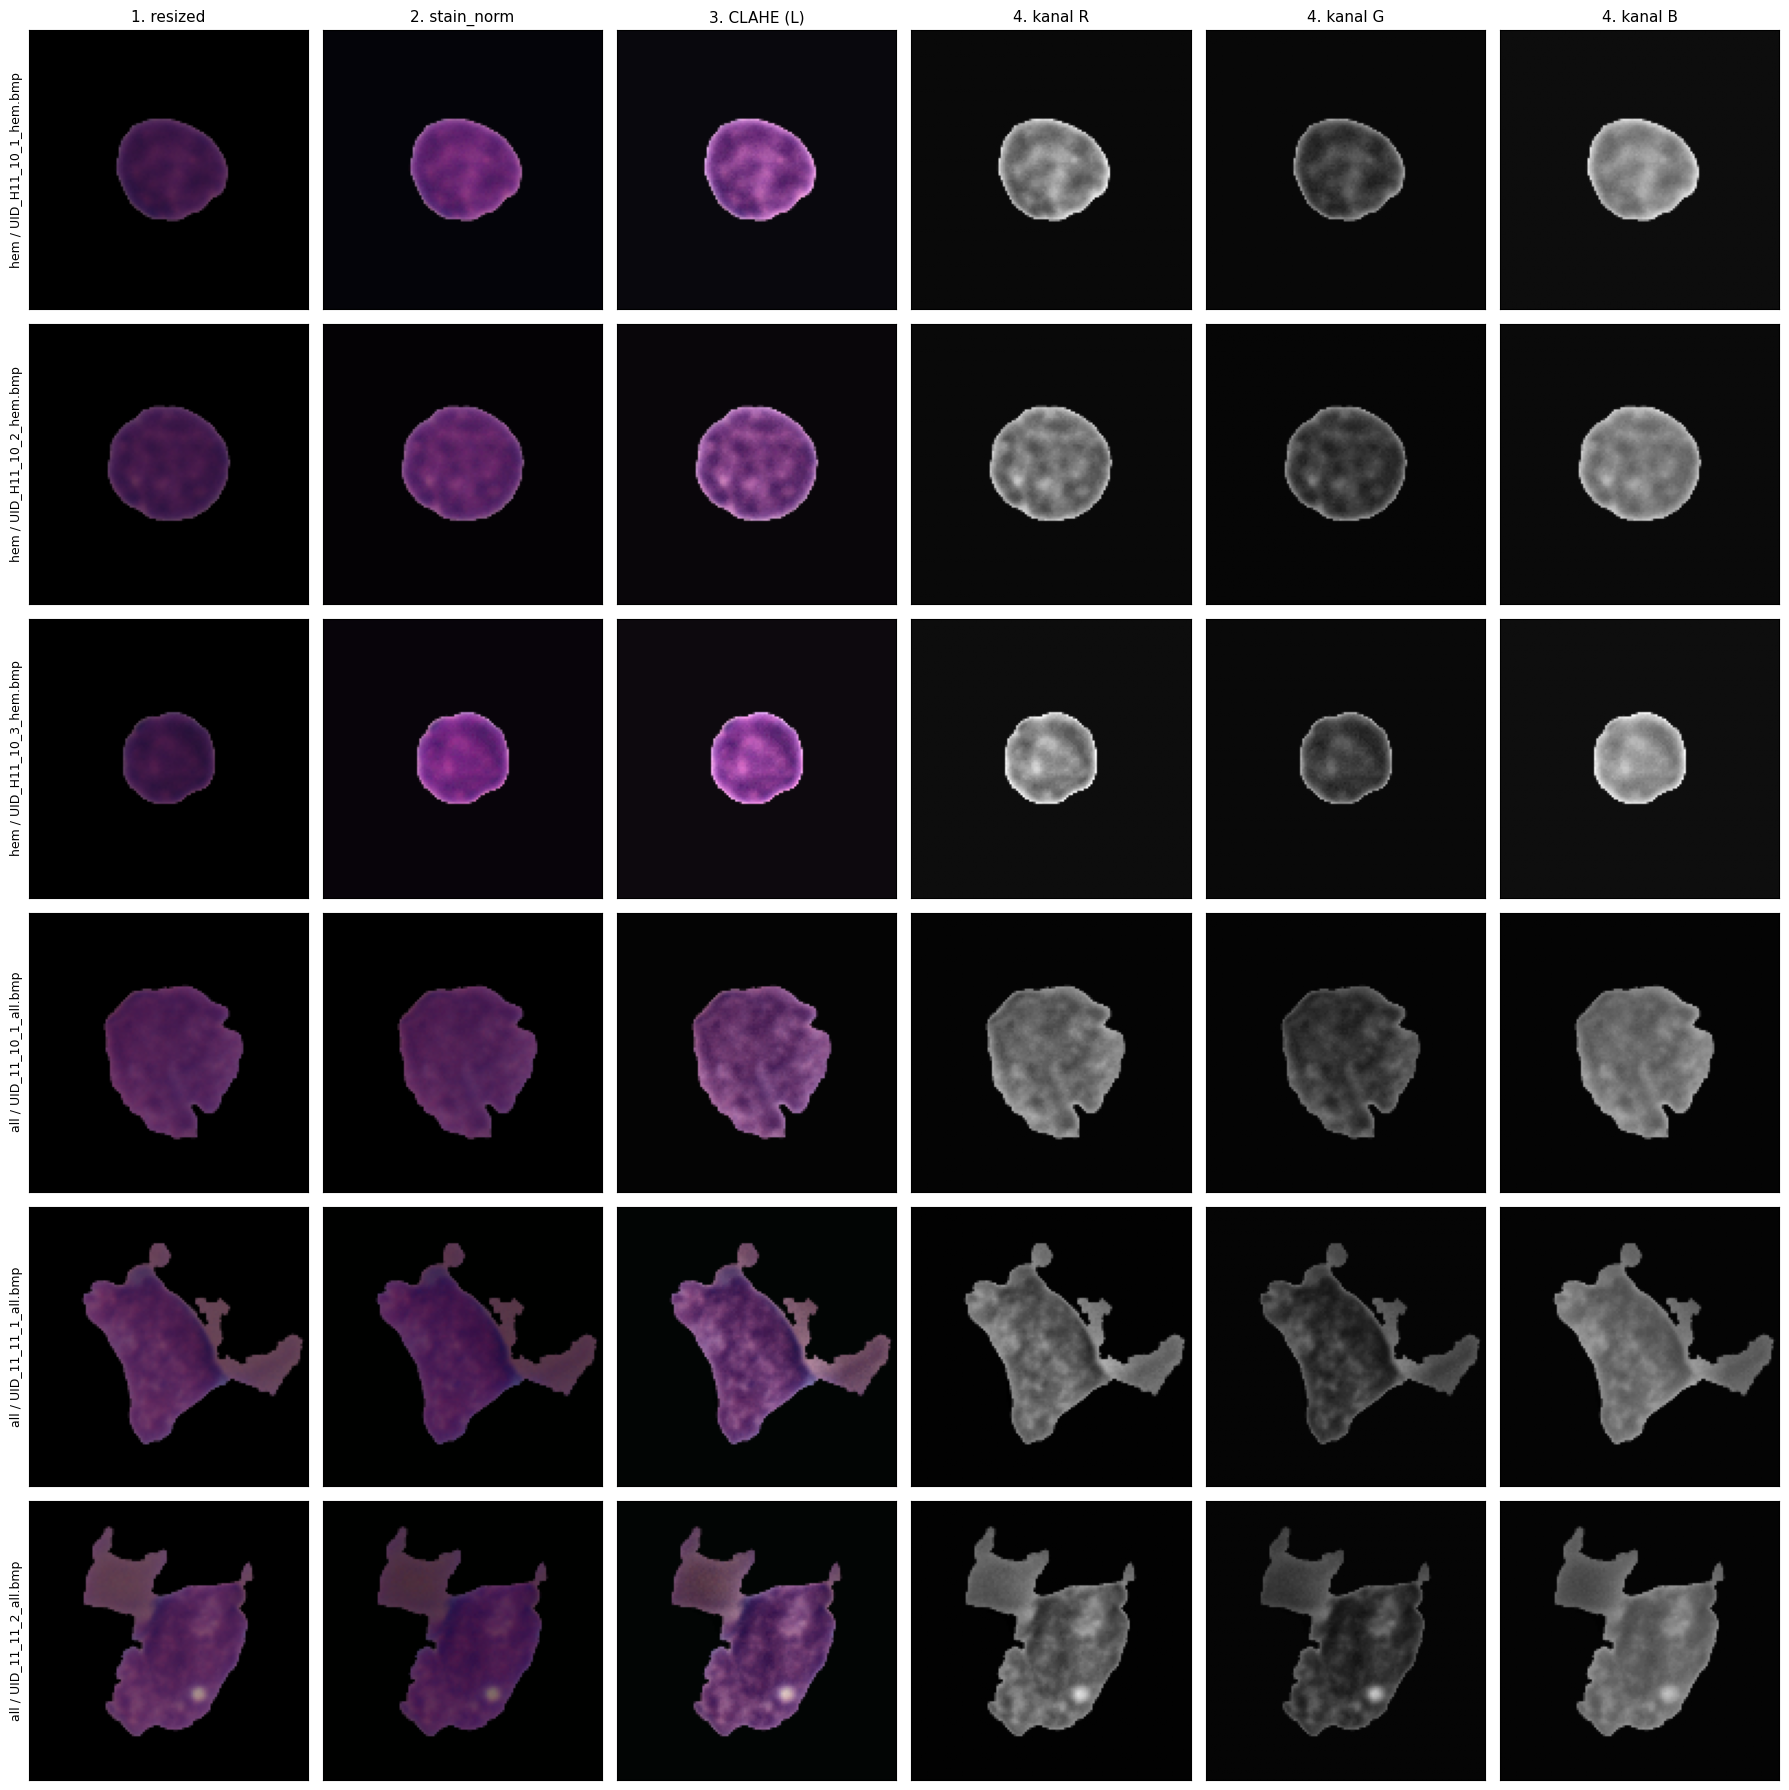

Zapisano 36 plikow + podglad do: output\preprocessing_stages


In [22]:
STAGES_DIR = os.path.join("output", "preprocessing_stages")
os.makedirs(STAGES_DIR, exist_ok=True)

N_SAMPLES_PER_CLASS = 3


def _load_and_resize(path, size=IMG_SIZE):
    bgr = cv2.imread(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return cv2.resize(rgb, size)


def _apply_stain_norm(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    mean = lab.reshape(-1, 3).mean(axis=0)
    std = lab.reshape(-1, 3).std(axis=0) + 1e-6
    lab = (lab - mean) * (REF_STD / std) + REF_MEAN
    return np.clip(lab, 0, 255).astype(np.uint8)  # w LAB


def _apply_clahe_on_l(lab_uint8):
    l, a, b = cv2.split(lab_uint8)
    l = _clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def _save_rgb(path, rgb):
    cv2.imwrite(path, cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


samples = []
for cls in ["hem", "all"]:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = sorted(os.listdir(cls_dir))[:N_SAMPLES_PER_CLASS]
    for f in files:
        samples.append((cls, f, os.path.join(cls_dir, f)))

rows = []
for cls, fname, fpath in samples:
    base = f"{cls}_{os.path.splitext(fname)[0]}"

    resized = _load_and_resize(fpath)
    lab_norm = _apply_stain_norm(resized)
    stain_rgb = cv2.cvtColor(lab_norm, cv2.COLOR_LAB2RGB)
    clahe_rgb = _apply_clahe_on_l(lab_norm)
    R, G, B = cv2.split(clahe_rgb)

    _save_rgb(os.path.join(STAGES_DIR, f"{base}_1_resized.png"), resized)
    _save_rgb(os.path.join(STAGES_DIR, f"{base}_2_stain_norm.png"), stain_rgb)
    _save_rgb(os.path.join(STAGES_DIR, f"{base}_3_clahe.png"), clahe_rgb)
    cv2.imwrite(os.path.join(STAGES_DIR, f"{base}_4_channel_R.png"), R)
    cv2.imwrite(os.path.join(STAGES_DIR, f"{base}_4_channel_G.png"), G)
    cv2.imwrite(os.path.join(STAGES_DIR, f"{base}_4_channel_B.png"), B)

    rows.append((f"{cls} / {fname}", [resized, stain_rgb, clahe_rgb, R, G, B]))

col_titles = ["1. resized", "2. stain_norm", "3. CLAHE (L)", "4. kanal R", "4. kanal G", "4. kanal B"]
fig, axes = plt.subplots(len(rows), 6, figsize=(18, 3 * len(rows)))
if len(rows) == 1:
    axes = np.array([axes])

for i, (title, imgs) in enumerate(rows):
    for j, img in enumerate(imgs):
        ax = axes[i, j]
        if img.ndim == 2:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(img)
        if i == 0:
            ax.set_title(col_titles[j], fontsize=11)
        if j == 0:
            ax.set_ylabel(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(STAGES_DIR, "_overview.png"), dpi=100, bbox_inches="tight")
plt.show()

print(f"Zapisano {len(samples) * 6} plikow + podglad do: {STAGES_DIR}")

## Budowa modelu CNN (transfer learning – VGG16)

In [23]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,585 (56.26 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Trening

In [24]:
EPOCHS = 12

os.makedirs("output", exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join("output", "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight,
)

Epoch 1/12
 85/111 ━━━━━━━━━━━━━━━━━━━━ 14s 548ms/step - accuracy: 0.5117 - loss: 2.1253

KeyboardInterrupt: 

## Ocena wyników

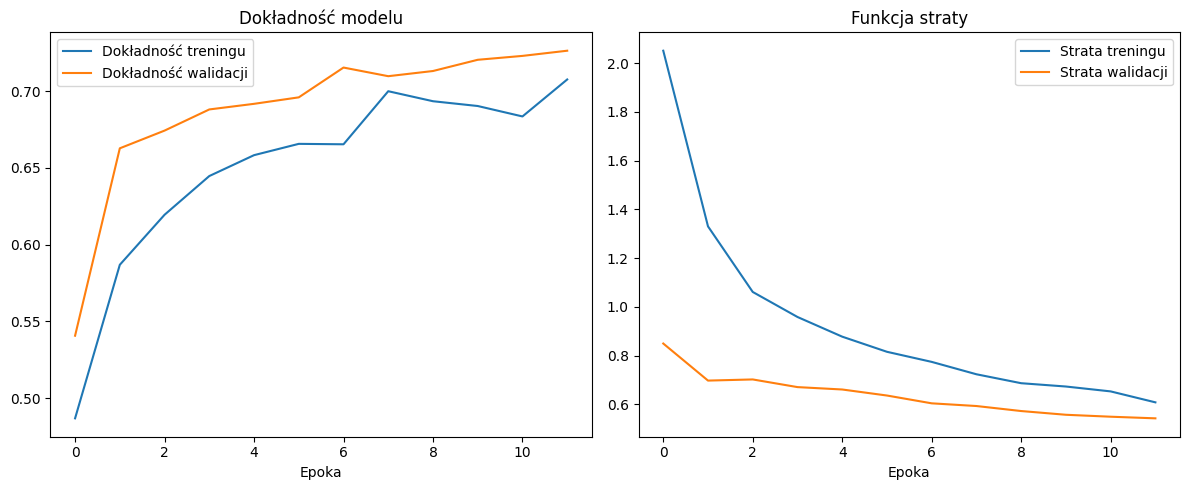

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Dokładność treningu")
plt.plot(epochs_range, val_acc, label="Dokładność walidacji")
plt.title("Dokładność modelu")
plt.xlabel("Epoka")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Strata treningu")
plt.plot(epochs_range, val_loss, label="Strata walidacji")
plt.title("Funkcja straty")
plt.xlabel("Epoka")
plt.legend()

plt.tight_layout()
plt.show()

112/112 ━━━━━━━━━━━━━━━━━━━━ 63s 559ms/step


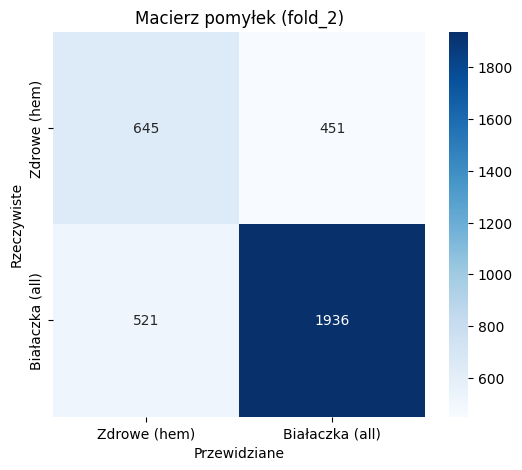

                 precision    recall  f1-score   support

   Zdrowe (hem)       0.55      0.59      0.57      1096
Białaczka (all)       0.81      0.79      0.80      2457

       accuracy                           0.73      3553
      macro avg       0.68      0.69      0.68      3553
   weighted avg       0.73      0.73      0.73      3553



In [ ]:
y_pred_prob = model.predict(val_ds_prepared)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = np.concatenate([y.numpy() for _, y in val_ds_prepared], axis=0).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Zdrowe (hem)", "Białaczka (all)"],
    yticklabels=["Zdrowe (hem)", "Białaczka (all)"],
)
plt.xlabel("Przewidziane")
plt.ylabel("Rzeczywiste")
plt.title("Macierz pomyłek (fold_2)")
plt.show()

print(classification_report(y_true, y_pred, target_names=["Zdrowe (hem)", "Białaczka (all)"]))

## Dyskusja wyników

Model VGG16 z transfer learningiem został wytrenowany na foldzie 0 i zwalidowany na foldzie 2. 
Kluczowe metryki do oceny medycznej to **recall klasy `all`** (ile chorych komórek zostało wykrytych) oraz 
macierz pomyłek – szczególnie liczba **false negative** (chore zakwalifikowane jako zdrowe), która w kontekście diagnostyki 
białaczki jest najkosztowniejszym błędem.

## Podsumowanie i wnioski

- Zastosowano transfer learning (VGG16 pre-trenowany na ImageNet) z zamrożoną siecią bazową i nowym klasyfikatorem.
- Zbiór treningowy: `data/fold_0/fold_0`, walidacyjny: `data/fold_2/fold_2` – klasy `all` (białaczka = 1) oraz `hem` (zdrowe = 0).
- W porównaniu do poprzedniej wersji (ręczne cechy na ~114 obrazach z `data/v1`) pracujemy na tysiącach obrazów, co lepiej odpowiada realnym warunkom diagnostycznym.
- Dalsze kroki: fine-tuning górnych warstw VGG16, augmentacja danych, ewaluacja na foldzie 1 jako niezależnym zbiorze testowym.

## Bibliografia

- [Źródło danych](https://www.kaggle.com/datasets/avk256/cnmc-leukemia/data)
- [Dokumentacja TensorFlow / Keras](https://www.tensorflow.org/api_docs)
- [VGG16 – Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556)
- [Dokumentacja biblioteki "NumPy"](https://numpy.org/doc/)
- [Dokumentacja biblioteki "matplotlib"](https://matplotlib.org/stable/index.html)
- [Dokumentacja biblioteki "seaborn"](https://seaborn.pydata.org/)
- [Dokumentacja biblioteki "scikit-learn"](https://scikit-learn.org/stable/documentation.html)